
#### **Helpful Resource:**
- [Python Reference](http://data8.org/sp24/reference/)

**Recommended Readings:**

* [Variability](https://inferentialthinking.com/chapters/14/2/Variability.html#)
* [Correlation](https://inferentialthinking.com/chapters/15/1/Correlation.html#)

In [1]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc
!pip install datascience

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [2]:
# Connect Google Drive to Colab so you can access your files
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/')

Mounted at /content/drive


In [3]:
# Run this cell, but please don't change it.

# These lines import the Numpy and Datascience modules.
import numpy as np
from datascience import *

# These lines do some fancy plotting magic.
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter('ignore', FutureWarning)

# 1. How Faithful is Old Faithful?

Old Faithful is a geyser in Yellowstone National Park that is famous for eruption on a fairly regular schedule.

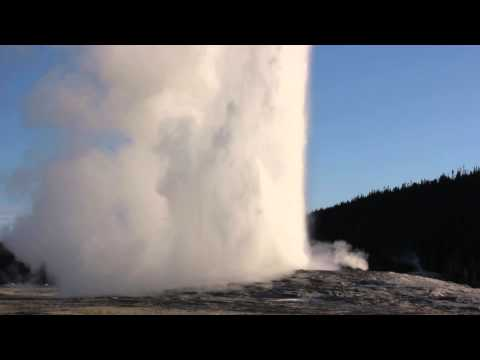

In [4]:
# For the curious: this is how to display a YouTube video in a
# Jupyter notebook.  The argument to YouTubeVideo is the part
# of the URL (called a "query parameter") that identifies the
# video.  For example, the full URL for this video is:
#   https://www.youtube.com/watch?v=wE8NDuzt8eg
from IPython.display import YouTubeVideo
YouTubeVideo("wE8NDuzt8eg")

Some of Old Faithful's eruptions last longer than others.  Whenever there is a long eruption, it is usually followed by an even longer wait before the next eruption. If you visit Yellowstone, you might want to predict when the next eruption will happen, so that you can see the rest of the park instead of waiting by the geyser.

Today, we will use a dataset on eruption durations and waiting times to see if we can make such predictions accurately with linear regression.

The dataset has one row for each observed eruption.  It includes the following columns:
- `duration`: Eruption duration, in minutes
- `wait`: Time between this eruption and the next, also in minutes

Run the next cell to load the dataset.

In [5]:
faithful = Table.read_table("./DS/faithful.csv")
faithful

duration,wait
3.6,79
1.8,54
3.333,74
2.283,62
4.533,85
2.883,55
4.7,88
3.6,85
1.95,51
4.35,85


**Question 1.0.** The following statements are the unordered steps of linear regression.  

1. Compute the parameters of the regression line: the slope and the intercept.
2. Evaluate the regression line by computing the line’s RMSE and analyzing the residuals plot.
3. Use the regression line to generate predictions for each x value.
4. Determine if linear regression is a reasonable method by visualizing your data and computing the correlation coefficient.

Make an array called `least_squares_order` that contains the correct order of a linear regression analysis, where the first item of the array is the first step of an linear regression analysis and the last item of the array is the last step of an linear regression analysis.


In [7]:
least_squares_order = make_array(4, 1, 3, 2)
least_squares_order

array([4, 1, 3, 2])

We would like to use linear regression to make predictions, but that won't work well if the data aren't roughly linearly related.  To check that, we should look at the data.

**Question 1.1.** Make a scatter plot of the data.  It's conventional to put the column we want to predict on the vertical axis and the other column on the horizontal axis.


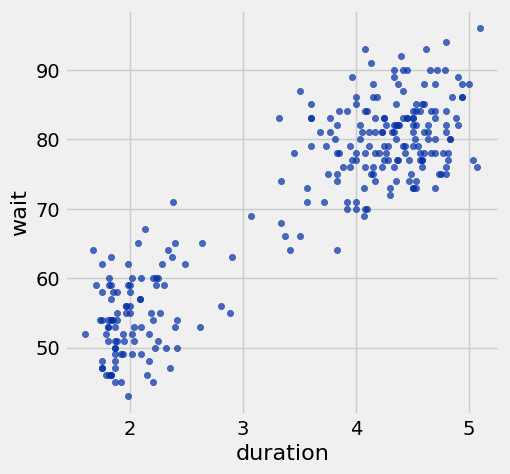

In [9]:
faithful.scatter('duration', 'wait')

**Question 1.2.** Are eruption duration and waiting time roughly linearly related based on the scatter plot above? Is this relationship positive?


The scatter plot shows a similar relationship between eruption time and waiting time, and this relationship is positive. That is, the timing of an eruption tends to adjust the waiting time until the next eruption.

We're going to continue with the assumption that they are linearly related, so it's reasonable to use linear regression to analyze this data.

We'd next like to plot the data in standard units. If you don't remember the definition of standard units, textbook section [14.2](https://www.inferentialthinking.com/chapters/14/2/Variability.html#standard-units) might help!

**Question 1.3.** Compute the mean and standard deviation of the eruption durations and waiting times.  **Then** create a table called `faithful_standard` containing the eruption durations and waiting times in standard units.  The columns should be named `duration (standard units)` and `wait (standard units)`.


In [10]:
duration_mean = faithful.column('duration').mean()
duration_std = faithful.column('duration').std()
wait_mean = faithful.column('wait').mean()
wait_std = faithful.column('wait').std()

faithful_standard = Table().with_columns(
    "duration (standard units)", (faithful.column('duration') - duration_mean) / duration_std,
    "wait (standard units)", (faithful.column('wait') - wait_mean) / wait_std)
faithful_standard

duration (standard units),wait (standard units)
0.0984989,0.597123
-1.48146,-1.24518
-0.135861,0.228663
-1.0575,-0.655644
0.917443,1.03928
-0.530851,-1.17149
1.06403,1.26035
0.0984989,1.03928
-1.3498,-1.46626
0.756814,1.03928


**Question 1.4.** Plot the data again, but this time in standard units.


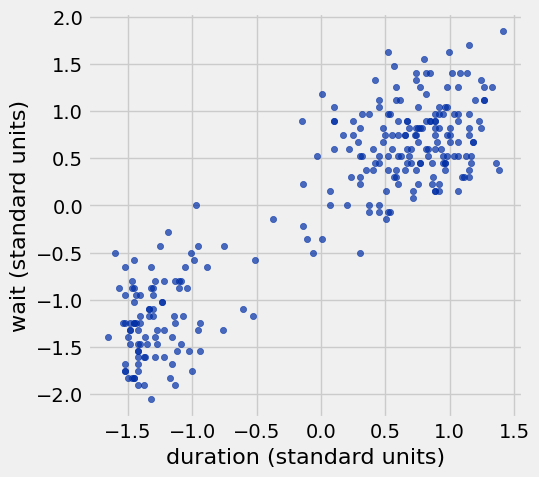

In [11]:
faithful_standard.scatter('duration (standard units)', 'wait (standard units)')

You'll notice that this plot looks the same as the last one!  However, the data and axes are scaled differently.  So it's important to read the ticks on the axes.

**Question 1.5.** Among the following numbers, which would you guess is closest to the correlation between eruption duration and waiting time in this dataset?

1. -1
2. 0
3. 1

Assign `correlation` to the number corresponding to your guess (either 1, 2 or 3).


In [12]:
correlation = 3
correlation

3

**Question 1.6.** Compute the correlation coefficient: `r`.  

*Hint:* Use `faithful_standard`.  Section [15.1](https://www.inferentialthinking.com/chapters/15/1/Correlation.html#calculating-r) explains how to do this.



In [13]:
r = (faithful_standard.column('duration (standard units)') * faithful_standard.column('wait (standard units)')).mean()
r

0.90081116832181318

## Submission

Make sure you have run all cells in your notebook in order before running the cell below, so that all images/graphs appear in the output. The cell below will generate a pdf file for you to submit. **Please save before exporting!**

In [15]:
# should change the directory and file name matching to yours
!jupyter nbconvert './DS/lab23(SSU).ipynb' --to pdf

[NbConvertApp] Converting notebook ./DS/lab23(SSU).ipynb to pdf
[NbConvertApp] Support files will be in lab23(SSU)_files/
[NbConvertApp] Making directory ./lab23(SSU)_files
[NbConvertApp] Writing 66940 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 135816 bytes to DS/lab23(SSU).pdf
